## Обучение моделей

В этом практическом задании две обязательные и одна дополнительная задача. 
<br>
*Обязательные задачи* нужно сделать для того, чтобы проверить, что вы действительно усвоили материал. Если у вас всё получилось, то можете переходить к следующей теме.
<br>
*Дополнительные задачи* для тех, кто хочет потренироваться с функцией feature_importances_ в деревьях. 
<br>
Удачи!

Цели практического задания: 

1.   Научиться обучать модель дерева решений с помощью sklearn.
2.   Научиться пользоваться параметром random_state в дереве решения 
3.   Научиться использовать знания о feature importances в дереве решения




## Обязательные задачи

### Описание датасета:
- `id`: идентификатор записи;
- `is_manufacturer_name`: признак производителя автомобиля;

- `region_*`: регион;
- `x0_*`: тип топлива;
- `manufacturer_*`: производитель;
- `short_model_*`: сокращённая модель автомобиля;
- `title_status_*`: статус;
- `transmission_*`: коробка передач;
- `state_*`: штат;
- `age_category_*`: возрастная категория автомобиля;

- `std_scaled_odometer`: количество пройденных миль (после стандартизации);
- `year_std`: год выпуска (после стандартизации);
- `lat_std`: широта (после стандартизации);
- `long_std`: долгота (после стандартизации);
- `odometer/price_std`: отношение стоимости к пробегу автомобиля (после стандартизации);
- `desc_len_std`: количество символов в тексте объявления о продаже (после стандартизации);
- `model_in_desc_std`: количество наименований модели автомобиля в тексте объявления о продаже (после стандартизации);
- `model_len_std`: длина наименования автомобиля (после стандартизации);
- `model_word_count_std`: количество слов в наименовании автомобиля (после стандартизации);
- `month_std`: номер месяца размещения объявления о продаже автомобиля (после стандартизации);
- `dayofweek_std`: день недели размещения объявления о продаже автомобиля (после стандартизации);
- `diff_years_std`: количество лет между годом производства автомобиля и годом размещения объявления о продаже автомобиля (после стандартизации);

- `price`: стоимость;
- `price_category`: категория цены.

1. *Обучение модели классификации*

Обучите модель классификации с помощью DecisionTreeClassifier как продемонстрировано в материалах. Для этого сделайте следующие шаги:

1. Загрузите файл с данными `vehicles_dataset_prepared.csv`
2. Положите копию датасета из п1 в `df_prepared`
3. Из `df_prepared` удалите колонки `price`, `odometer/price_std`
4. Поделите датасет на тренировочную и тестовую выборки
5. Обучите модель дерева решений на тренировочной выборке
6. Сделайте предикт на тестовой выборке
7. Замерьте точность на тестовой выборке и выведите матрицу ошибок 

In [43]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix 

In [93]:
# Здесь ваш код
df = pd.read_csv('data/vehicles_dataset_prepared.csv')
df_prepared = df.copy()
df_prepared = df_prepared.drop(['price', 'odometer/price_std'], axis=1)

x = df_prepared.drop(['price_category'], axis=1)
y = df_prepared.price_category

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [95]:
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.6715176715176715

In [97]:
confusion_matrix(y_test, y_pred)

array([[739,  53, 205],
       [ 50, 687, 216],
       [189, 235, 512]])

2. *Random_state в дереве решений*

Попробуйте 10 раз обучить `clf = DecisionTreeClassifier()` на одних и тех же данных и замерьте значение точности. Покажите, что точность изменяется от прогона к прогону. 

Попробуйте сделать такой же эксперимент, но добавьте входной параметр random_state равным какому то числу, например `clf2 = DecisionTreeClassifier(random_state=42)`. Теперь повторите эксперимент. Меняется ли точность на тестовой выборке от прогона к прогону?

In [118]:
# Ваш код для 1 эксперимента
accuracy = []

for i in range(10):
    clf = DecisionTreeClassifier()
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy.append(acc)
print(accuracy)

[0.6756756756756757, 0.6729036729036729, 0.6694386694386695, 0.667013167013167, 0.6708246708246708, 0.6711711711711712, 0.6704781704781705, 0.6708246708246708, 0.665973665973666, 0.6694386694386695]


In [120]:
# Ваш код для 2 эксперимента
accuracy2 = []

for i in range(10):
    clf2 = DecisionTreeClassifier(random_state=42)
    clf2.fit(x_train, y_train)
    y_pred = clf2.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy2.append(acc)
print(accuracy2)

[0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725, 0.6725571725571725]


Узнайте, за что отвечает параметр random_state.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


Так же, как и при делении выборки на треин и тест, в объявлении дерева решении `random_state` позволяет вам обеспечить "воспроизводимость" результатов. `Random_state` - это семя генератора случайных чисел, которое используется для выбора фичей во время поиска фичи для наилучшего разделения в узле. 

Алгоритм работает таким образом, что выбирает n фичей случайным образом, из которых затем выбирает лучшую фичу для разделения. Чтобы зафиксировать множество фичей, которые выбираются случайным образом во время обучения, нужно установить параметр `random_state` равным какому-то числу. 

## Дополнительные задачи





Рассчитайте feature_importances для обученной модели. Удалите все фичи с нулевым весом из тренировочного и тестового датасетов, и заново обучите модель. Проверьте, что качество модели не ухудшилось. 

Затем заново рассчитайте feature_importances и визулизируйте важность первых 20 фичей с помощью горизонтального bar plot.

In [122]:
import matplotlib.pyplot as plt
import numpy as np

In [136]:
# Здесь ваш код
importances = clf.feature_importances_
#features = x_train.columns
zero_importances_features = x_train.columns[importances == 0]

x_train_cleaned = x_train.drop(columns=zero_importances_features)
x_test_cleaned = x_test.drop(columns=zero_importances_features)

clf_cleaned = DecisionTreeClassifier(random_state=42)
clf_cleaned.fit(x_train_cleaned, y_train)

y_pred_cleaned = clf_cleaned.predict(x_test_cleaned)
acc_cleaned = accuracy_score(y_pred_cleaned, y_test)

print(f'Accuracy after deleting Zero importances: {acc_cleaned:.4}')

Accuracy after deleting Zero importances: 0.6684


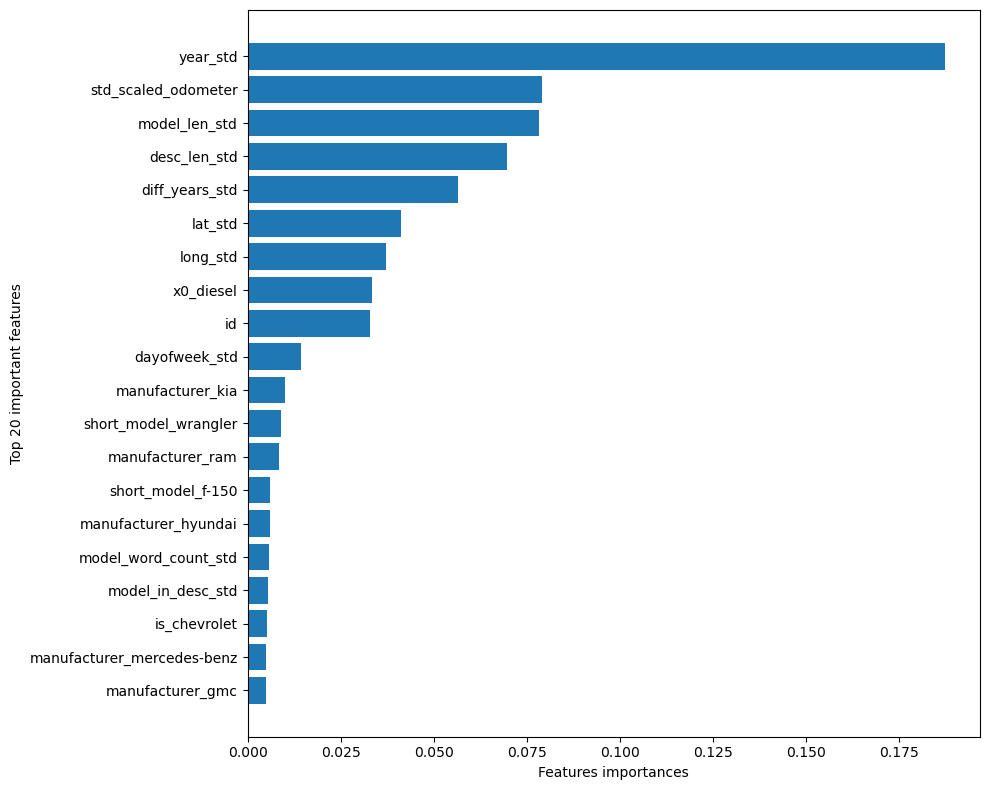

In [148]:
sorted_features = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)
top_features = sorted_features[:20]

feature_names, importance_values = zip(*top_features)

plt.figure(figsize=(10, 8))
plt.barh(feature_names, importance_values)
plt.xlabel('Features importances')
plt.ylabel('Top 20 important features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [53]:
# Решение 1
df = pd.read_csv('data/vehicles_dataset_prepared.csv')

df_prepared = df.copy()
df_prepared = df_prepared.drop(['price', 'odometer/price_std'], axis=1)

In [55]:
x = df_prepared.drop(['price_category'], axis=1)
y = df_prepared['price_category']

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [100]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [102]:
predicted_train = clf.predict(x_train)
predicted_test = clf.predict(x_test)

In [104]:
accuracy_score(y_test, predicted_test)

0.6742896742896742

In [106]:
confusion_matrix(y_test, predicted_test)

array([[737,  53, 207],
       [ 45, 687, 221],
       [185, 229, 522]])

In [ ]:
# Решение 2
# 1 эксперимент

clf = DecisionTreeClassifier()

for i in range(10):
  clf.fit(x_train, y_train)

  predicted_train = clf.predict(x_train)
  predicted_test = clf.predict(x_test)

  print(accuracy_score(y_test, predicted_test), end ='--')

0.6642411642411642--0.6725571725571725--0.6729036729036729--0.667013167013167--0.6746361746361746--0.6687456687456688--0.6694386694386695--0.6673596673596673--0.6787941787941788--0.6711711711711712--

In [ ]:
# Решение 2
# 2 эксперимент

clf2 = DecisionTreeClassifier(random_state=42)

for i in range(10):
  clf2.fit(x_train, y_train)

  predicted_train = clf2.predict(x_train)
  predicted_test = clf2.predict(x_test)

  print(accuracy_score(y_test, predicted_test), end ='--')

0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--0.6704781704781705--